# World Map

/tmp/ipykernel_102083/333192673.py:53: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


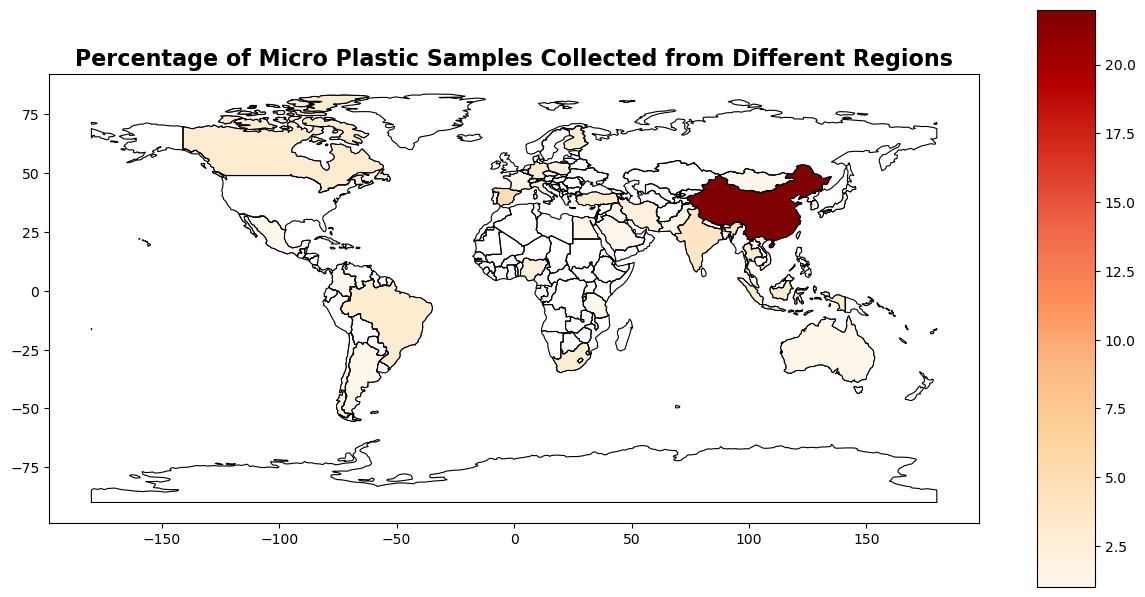

In [38]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Data for country percentages
country_percentage = {
    "China": 22,
    "Saudi Arabia": 1,
    "USA": 8,
    "Nigeria": 2,
    "Canada": 3,
    "Argentina": 1,
    "Indonesia": 3,
    "Portugal": 1,
    "Vietnam": 3,
    "Taiwan": 1,
    "Nederlands": 3,
    "South Korea": 1,
    "Italy": 2,
    "India": 4,
    "Australia": 1,
    "Tanzania": 1,
    "Brazil": 3,
    "Thailand": 3,
    "Denmark": 2,
    "Hungary": 2,
    "Colombia": 1,
    "Pakistan": 1,
    "Finland": 3,
    "Mongolia": 1,
    "Spain": 5,
    "Bangladesh": 1,
    "Nepal": 1,
    "UK": 2,
    "South Africa": 3,
    "Switzerland": 1,
    "Japan": 1,
    "France": 1,
    "Germany": 3,
    "Hong Kong": 2,
    "Iran": 2,
    "Iraq": 1,
    "Chile": 1,
    "Mexico": 1,
    "Malaysia": 1,
    "Turkey": 3,
    "Lebanon": 1,
    "Egypt": 1,
    "Poland": 2
}

# Load world shapefile
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Map percentage data to the world GeoDataFrame
world['Percentage'] = world['name'].map(country_percentage)

# Plot the world map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Set the sea color
# ax.set_facecolor('lightblue')

# Plot only regions with data
world_with_data = world.dropna(subset=['Percentage'])
heatmap = world_with_data.plot(
    column='Percentage',
    cmap='OrRd',  # Use the crest colormap
    legend=True,
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    legend_kwds={'shrink': 0.75, 'aspect': 10}
)

# Plot country boundaries for all regions (to ensure borders are visible even for uncolored countries)
world.boundary.plot(ax=ax, linewidth=0.8, color='black')

# # Annotate country names
# for idx, row in world_with_data.iterrows():
#     centroid = row['geometry'].centroid
#     ax.text(
#         centroid.x, centroid.y, row['name'],
#         fontsize=8, ha='center', color='darkblue', weight='bold'
#     )

# Add a title
plt.title("Percentage of Micro Plastic Samples Collected from Different Regions", fontsize=16, fontweight='bold')

# Show the map
plt.show()


In [39]:
# Read the text file
with open("abstracts.txt", "r") as file:
    text = file.read()

In [40]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download NLTK punkt resources in this environment and working directory
nltk.download('punkt', download_dir='.')
nltk.download('punkt_tab', download_dir='.')
nltk.download('stopwords', download_dir='.')


# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('stopwords')

# Tokenize and preprocess
tokens = word_tokenize(text)
stop_words = set(stopwords.words('english'))
keywords = [word.lower() for word in tokens if word.isalnum() and word.lower() not in stop_words]

[nltk_data] Downloading package punkt to ....
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to ....
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to ....
[nltk_data]   Package stopwords is already up-to-date!


In [41]:
from nltk.stem import WordNetLemmatizer
from collections import Counter
import nltk

# Download WordNet data for lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Lemmatize all keywords
lemmatized_keywords = [lemmatizer.lemmatize(word) for word in keywords]

# Count keyword frequencies
keyword_freq = Counter(lemmatized_keywords)
common_keywords = keyword_freq.most_common(50)  # Top 20 keywords
print("Top Keywords:", common_keywords)

Top Keywords: [('microplastics', 138), ('mp', 99), ('study', 48), ('microplastic', 47), ('environment', 46), ('review', 45), ('environmental', 43), ('research', 41), ('pollution', 39), ('effect', 39), ('human', 33), ('plastic', 33), ('water', 32), ('source', 31), ('health', 31), ('impact', 31), ('aquatic', 30), ('ecosystem', 30), ('treatment', 26), ('fish', 26), ('also', 25), ('method', 25), ('marine', 22), ('soil', 21), ('exposure', 18), ('waste', 18), ('system', 18), ('concern', 17), ('concentration', 17), ('current', 17), ('process', 17), ('potential', 17), ('freshwater', 16), ('pollutant', 15), ('data', 15), ('knowledge', 15), ('management', 15), ('plant', 15), ('understanding', 15), ('organic', 15), ('analysis', 14), ('wastewater', 14), ('strategy', 14), ('significant', 14), ('widespread', 13), ('including', 13), ('particle', 13), ('finding', 13), ('food', 13), ('chemical', 13)]


[nltk_data] Downloading package wordnet to /home/abhowmik/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/abhowmik/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [42]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# # Split the text into individual abstracts if needed
# with open("abstracts.txt", "r") as file:
#     abstracts = file.readlines()

# # Apply TF-IDF
# vectorizer = TfidfVectorizer(max_features=50, stop_words='english')  # Top 50 terms
# tfidf_matrix = vectorizer.fit_transform(abstracts)
# keywords_tfidf = vectorizer.get_feature_names_out()
# print("TF-IDF Keywords:", keywords_tfidf)


In [43]:
# from rake_nltk import Rake

# rake = Rake()  # By default, uses NLTK's stopwords
# rake.extract_keywords_from_text(text)
# ranked_phrases = rake.get_ranked_phrases()  # Ranked keywords/phrases
# print("RAKE Keywords:", ranked_phrases[:20])  # Top 20 phrases


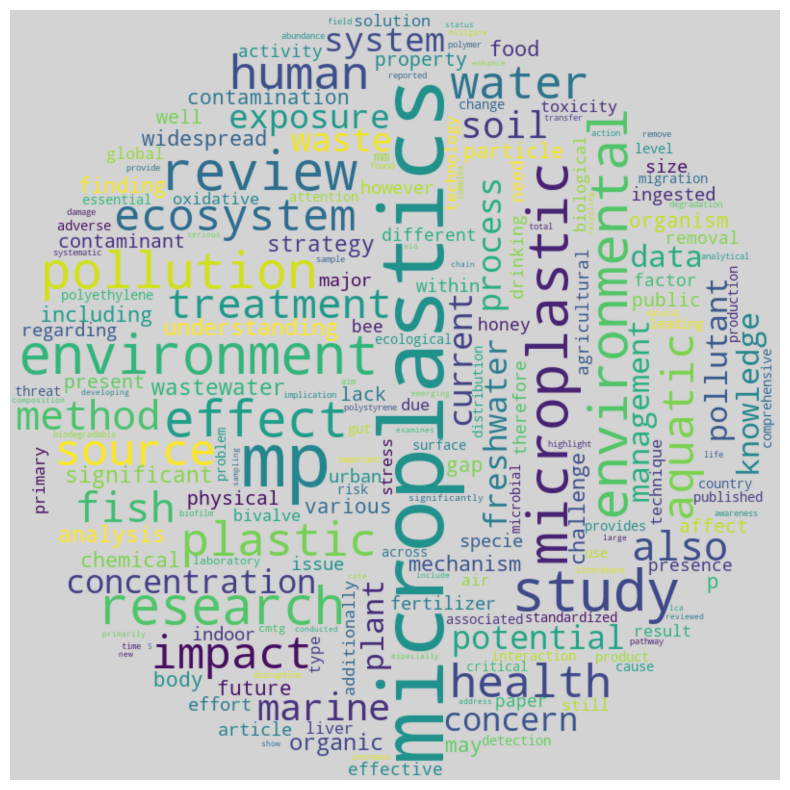

In [44]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

# Create a circular mask
x, y = np.ogrid[:800, :800]
mask = (x - 400) ** 2 + (y - 400) ** 2 > 400 ** 2
mask = 255 * mask.astype(int)

wordcloud = WordCloud(
    width=800, height=800, background_color='lightgray', mask=mask
).generate_from_frequencies(keyword_freq)

plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='gaussian')
plt.axis('off')
plt.show()
